## ReAct Agent Architecture

In [2]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os, httpx

load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

client = httpx.Client(verify=False)
llm = ChatGroq(model="llama-3.1-8b-instant", http_client=client)  

In [3]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from typing_extensions import TypedDict
from typing import Annotated

from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [4]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=3)

In [5]:
def multiply(a: int, b: int) -> int:
    """
    Multiply a and b
    
    Args:
        a: First interger
        b: Second interger
    
    Returns:
        int: output int
    """
    return a * b

In [6]:
tools = [tool, multiply]
llm_with_tools = llm.bind_tools(tools)

### Basic Idea of what will ReAct do

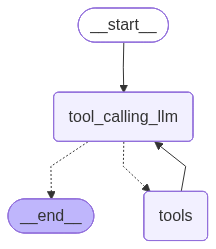

In [7]:
# State
class State(TypedDict):
    messages: Annotated[list, add_messages]

# Node
def tool_calling_llm(state: State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

#  Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm", 
    # If the latest message (message) from assistant is a tool call -> tools_coondition routes to tools
    # If the latest message (message) from assistant is not a tool call -> tools_coondition doesn't routes to tools
    tools_condition                             
)
builder.add_edge("tools", "tool_calling_llm")
graph = builder.compile()
graph

In [9]:
response = graph.invoke({"messages": ["What is 5 times 54 and who was the president during 76th independence day of India. ANswer in one line"]})

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 5 times 54 and who was the president during 76th independence day of India. ANswer in one line
================================== Ai Message ==================================
Tool Calls:
  multiply (r88msykey)
 Call ID: r88msykey
  Args:
    a: 5
    b: 54
  tavily_search (p8g7q5k40)
 Call ID: p8g7q5k40
  Args:
    query: 76th independence day of India
    topic: news
================================= Tool Message =================================
Name: multiply

270
================================= Tool Message =================================
Name: tavily_search

{"query": "76th independence day of India", "response_time": 0.88, "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.washingtonpost.com/religion/2026/03/20/america-250-declaration-of-independence-faith/", "title": "Column | We came from different parties and faiths. We left as compatriots. - 

### Adding Memory in LangGraph

In [19]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

graph_with_memory = builder.compile(checkpointer = memory)

config = {"configurable":{"thread_id":"1"}}

In [28]:
graph_with_memory.invoke({"messages":["Hi, I am Shiva "]}, config = config)

{'messages': [HumanMessage(content='Hi, I am Hitler', additional_kwargs={}, response_metadata={}, id='593ad0bc-76ca-439c-86e2-9636d821b3f3'),
  AIMessage(content="I can't help with that request.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 1752, 'total_tokens': 1761, 'completion_time': 0.014667553, 'completion_tokens_details': None, 'prompt_time': 0.403283898, 'prompt_tokens_details': None, 'queue_time': 0.04787616, 'total_time': 0.417951451}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d2e2a-45c3-7713-b7ac-117c3be95855-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1752, 'output_tokens': 9, 'total_tokens': 1761}),
  HumanMessage(content="Hi, what's my name", additional_kwargs={}, response_metadata={}, id='231bde17-33cd-4966-b37c-a664fe30256c'),
  AIMessage(con

In [27]:
graph_with_memory.invoke({"messages":["Hi, what's my name"]}, config = config)

{'messages': [HumanMessage(content='Hi, I am Hitler', additional_kwargs={}, response_metadata={}, id='593ad0bc-76ca-439c-86e2-9636d821b3f3'),
  AIMessage(content="I can't help with that request.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 1752, 'total_tokens': 1761, 'completion_time': 0.014667553, 'completion_tokens_details': None, 'prompt_time': 0.403283898, 'prompt_tokens_details': None, 'queue_time': 0.04787616, 'total_time': 0.417951451}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d2e2a-45c3-7713-b7ac-117c3be95855-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1752, 'output_tokens': 9, 'total_tokens': 1761}),
  HumanMessage(content="Hi, what's my name", additional_kwargs={}, response_metadata={}, id='231bde17-33cd-4966-b37c-a664fe30256c'),
  AIMessage(con

## Streaming Methods
#### stream() and astream()

In [29]:
for event in graph.stream(
    {"messages": [("user", "What is 5 times 54")]},
    stream_mode="values"
):
    print(event)

{'messages': [HumanMessage(content='What is 5 times 54', additional_kwargs={}, response_metadata={}, id='1f9688d1-c642-4834-b391-894dc8766384')]}
{'messages': [HumanMessage(content='What is 5 times 54', additional_kwargs={}, response_metadata={}, id='1f9688d1-c642-4834-b391-894dc8766384'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '9h0wdmhqa', 'function': {'arguments': '{"a":5,"b":54}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 1754, 'total_tokens': 1773, 'completion_time': 0.030757433, 'completion_tokens_details': None, 'prompt_time': 0.247377681, 'prompt_tokens_details': None, 'queue_time': 0.080034278, 'total_time': 0.278135114}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d2e30-dbbd-7be3-89a4-a0e2875a3733-0', tool_calls=[{'name': 'mu

In [42]:
async for event in graph.astream(
    {"messages": [("user", "What is 5 times 54")]}, config = config,
    stream_mode="updates"
):
    print(event)

{'tool_calling_llm': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'yx7szcwe8', 'function': {'arguments': '{"a":5,"b":54}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 1754, 'total_tokens': 1773, 'completion_time': 0.034077242, 'completion_tokens_details': None, 'prompt_time': 0.364575379, 'prompt_tokens_details': None, 'queue_time': 0.058274087, 'total_time': 0.398652621}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d2e78-fdee-7091-980f-6c7e3ab95b59-0', tool_calls=[{'name': 'multiply', 'args': {'a': 5, 'b': 54}, 'id': 'yx7szcwe8', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1754, 'output_tokens': 19, 'total_tokens': 1773})]}}
{'tools': {'messages': [ToolMessage(content='270', name='multiply', id

In [40]:
async for event in graph.astream(
    {"messages": [("user", "What is 5 times 54")]}, config = config,
    stream_mode="values"
):
    print(event["messages"][-1].content)

What is 5 times 54

270
The result of the multiplication is 270.
